<a href="https://colab.research.google.com/github/robertopsouto/BRAMS-5.2-modified/blob/main/notebooks/Escola_VeraoLNCC_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Workshop da Escola de Verão do Laboratório Nacional de Computação Científica (LNCC)

###Mini-curso: Assimilação de Dados por Aprendizado de Máquina


####Neste notebook iremos desenvolver um modelo de Assimilação de Dados de Temperautua baseado em Aprendizado de Máquina.

####Para isso, carregaremos um conjunto de dados de observação e treinaremos um algoritmo baseado em Árvores de Decisão e *Boosting*, uma técnica baseada em aprendizado por *ensemble*.

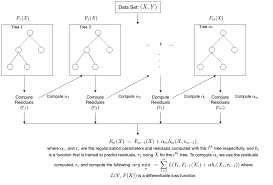





##Instalações necessárias

In [ ]:
!pip install cartopy

##Importações dos pacotes necessários

In [ ]:
import os
import datetime
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy import signal
import cartopy.crs as ccrs
from sklearn.utils import shuffle
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
from matplotlib import pyplot as plt
from matplotlib import colorbar, colors
from sklearn.metrics import mean_squared_error

##Funções auxiliares

In [ ]:
def expand(dataframe, coluna, variavel):
  result = {}
  for i in dataframe[variavel].unique():
    coluna_resutl = dataframe.loc[dataframe[variavel] == i][coluna].to_numpy()
    result[int(i)] = coluna_resutl

  return result

def plot(longi, lat, data, title, x=(-58.9,-47.699), y=(-36.2,-25.1),
         figsize=(10,8.5)):

    fig = plt.figure(figsize=figsize)

    # Set the axes using the specified map projection
    ax=plt.axes(projection=ccrs.PlateCarree())

    # Make a filled contour plot
    cs=ax.contourf(longi.T, lat.T, data.T,
                transform = ccrs.PlateCarree(),cmap='jet',extend='both')

    ax.coastlines()
    states = cfeature.NaturalEarthFeature(
                category='cultural',
                name='admin_0_boundary_lines_land', #admin_1_states_provinces - admin_0_boundary_lines_land
                scale='10m',
                facecolor='none',
                edgecolor='black')

    cbar = plt.colorbar(cs,shrink=0.5,orientation='vertical',
                        label='Temperatura 2M')
    ax.add_feature(states, linewidth=2, edgecolor="black")
    ax.add_feature(cfeature.LAND)

    ax.set_xlim(x)
    ax.set_ylim(y)
    ax.coastlines()
    ax.set_title(title)

##Download dos dados

In [ ]:
!gdown https://drive.google.com/uc?id=1_RHG_Gos-EDP5w0CoNXlrWDXsawtN9br
!gdown https://drive.google.com/uc?id=1KnMf7PMn8ZTZfD0-HF8BjoMltZS4l5Bw

##Lendo conjuntos de treino e teste

In [ ]:
PATH="/content/"

#treino
df_train = pd.read_csv(PATH+'train.csv', header=0)
df_train = df_train.drop(columns=['Unnamed: 0'], axis=1)

#teste
df_test = pd.read_csv(PATH+'test.csv', header=0)
df_test = df_test.drop(columns=['Unnamed: 0'], axis=1)

print(df_train.shape)
print(df_test.shape)

In [ ]:
df_train.head()

### Valores de Latitude e Longitude, Mês e Ano

In [ ]:
df_train['LAT'].min(), df_train['LAT'].max()

In [ ]:
df_train['LONG'].min(), df_train['LONG'].max()

In [ ]:
df_train['MES'].unique(), df_train['ANO'].unique()

In [ ]:
df_test['MES'].unique(), df_test['ANO'].unique()

### visualização dos dados

#### a grade estudada tem dimensões 129x139, totalizando 17931 pontos

In [ ]:
ativacao_dia_teste = df_train[(df_train['MES'] == 7) & (df_train['DIA'] == 6)]

lat = expand(ativacao_dia_teste, 'LAT', variavel='PONTO DE GRADE Y')
lat = pd.DataFrame(lat)

longi = expand(ativacao_dia_teste, 'LONG', variavel='PONTO DE GRADE Y')
longi = pd.DataFrame(longi)

rotulos = expand(ativacao_dia_teste, 'TARGET', variavel='PONTO DE GRADE Y')
rotulos = pd.DataFrame(rotulos)

plot(longi, lat, rotulos, 'Análise 3DVar', x=(-58.9,-47.699), y=(-36.2,-25.1),
     figsize=(10,8.5))

##Conjunto de treino e validação

In [ ]:
df_val = df_train[df_train['MES'] == 8]
df_train = df_train[df_train['MES'] <= 7]

In [ ]:
y_train = df_train['TARGET'].copy()
X_train = df_train[['LAT', 'LONG', 'PONTO DE GRADE Y', 'PONTO DE GRADE X',
                    'VAL. SIMULACAO', 'VALOR DE OBSERVACAO', 'MES', 'DIA']].copy()
X_train.head()

In [ ]:
y_val = df_val['TARGET'].copy()
X_val = df_val[['LAT', 'LONG', 'PONTO DE GRADE Y', 'PONTO DE GRADE X',
                    'VAL. SIMULACAO', 'VALOR DE OBSERVACAO', 'MES', 'DIA']].copy()
X_val.head()

##Conjunto de teste

In [ ]:
y_test = df_test['TARGET'].copy()
X_test = df_test[['LAT', 'LONG', 'PONTO DE GRADE Y', 'PONTO DE GRADE X',
                    'VAL. SIMULACAO', 'VALOR DE OBSERVACAO', 'MES', 'DIA']].copy()
X_test.head()

###Treinamento do algoritmo -  XGBoost



In [ ]:
my_model = xgb.XGBRegressor(objective='reg:squarederror',
                            n_estimators = 500,
                            max_depth = 5, early_stopping_rounds=10)

evalset = [(X_train[['VALOR DE OBSERVACAO']].values,
            y_train.values),
           (X_val[['VALOR DE OBSERVACAO']].values,
            y_val.values)]

trained_model = my_model.fit(X_train[['VALOR DE OBSERVACAO']].values,
                             y_train.values,
            eval_set=evalset, verbose=True)


In [ ]:
preds = trained_model.predict(X_test[['VALOR DE OBSERVACAO']].values)
mse_test = mean_squared_error(y_test, preds)
print(f'Test MSE: {mse_test}')

In [ ]:
#grava os resultados no arquivo .csv
results_model = X_test.copy()
results_model['target'] = y_test
results_model['predictions'] = preds
results_model.head()

In [ ]:
#results_model.to_csv('results.csv')

##Visualização dos resultados

In [ ]:
ativacao_dia_teste = results_model[(results_model['MES'] == 7) & (results_model['DIA'] == 6)]
ativacao_dia_teste.shape

In [ ]:
fg = expand(ativacao_dia_teste, 'VAL. SIMULACAO', variavel='PONTO DE GRADE Y')
fg = pd.DataFrame(fg)

plot(longi, lat, fg, 'FG', x=(-58.9,-47.699), y=(-36.2,-25.1),
     figsize=(10,8.5))

In [ ]:
lat = expand(ativacao_dia_teste, 'LAT', variavel='PONTO DE GRADE Y')
lat = pd.DataFrame(lat)

longi = expand(ativacao_dia_teste, 'LONG', variavel='PONTO DE GRADE Y')
longi = pd.DataFrame(longi)

In [ ]:
rotulos = expand(ativacao_dia_teste, 'target', variavel='PONTO DE GRADE Y')
rotulos = pd.DataFrame(rotulos)

plot(longi, lat, rotulos, 'Análise 3DVar', x=(-58.9,-47.699), y=(-36.2,-25.1),
     figsize=(10,8.5))

In [ ]:
preds = expand(ativacao_dia_teste, 'predictions', variavel='PONTO DE GRADE Y')
preds = pd.DataFrame(preds)

plot(longi, lat, preds, 'Análise XGBoost', x=(-58.9,-47.699), y=(-36.2,-25.1),
     figsize=(10,8.5))

In [ ]:
plot(longi, lat, abs(preds-rotulos), 'Diferença entre análises', x=(-58.9,-47.699), y=(-36.2,-25.1),
     figsize=(10,8.5))